In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Import and interpolate NIST data

In [2]:
NIST = pd.read_excel(r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\X-ray spectrum calculations\NIST data water.xlsx")
#convert to keV
NIST['Energy'] = 1000*NIST['Energy']
#Calculate mass energy absorption over mass attenuation ratio
NIST['Ratio'] = NIST['Mass En Abs']/NIST['Mass Att']
#Truncate after Energy that is relevant for us
NIST = NIST.iloc[0:NIST[NIST['Energy']>225].index.tolist()[0]+1]
#Remove 1.5 keV
NIST = NIST[NIST['Energy']!=1.5]
NIST = NIST.reset_index(drop=True)
print(NIST)

    Energy   Mass Att  Mass En Abs     Ratio
0      1.0  4078.0000   4065.00000  0.996812
1      2.0   617.3000    615.20000  0.996598
2      3.0   192.9000    191.70000  0.993779
3      4.0    82.7800     81.91000  0.989490
4      5.0    42.5800     41.88000  0.983560
5      6.0    24.6400     24.05000  0.976055
6      8.0    10.3700      9.91500  0.956123
7     10.0     5.3290      4.94400  0.927754
8     15.0     1.6730      1.37400  0.821279
9     20.0     0.8096      0.55030  0.679718
10    30.0     0.3756      0.15570  0.414537
11    40.0     0.2683      0.06947  0.258927
12    50.0     0.2269      0.04223  0.186117
13    60.0     0.2059      0.03190  0.154930
14    80.0     0.1837      0.02597  0.141372
15   100.0     0.1707      0.02546  0.149151
16   150.0     0.1505      0.02764  0.183654
17   200.0     0.1370      0.02967  0.216569
18   300.0     0.1186      0.03192  0.269140


In [3]:
#Make a copy for interpolation, take over values from original data
Expanded_data = pd.DataFrame(columns=['Energy', 'Mass Att', 'Mass En Abs'])
Expanded_data['Energy'] = np.arange(1, 301, 1)
for energy in Expanded_data['Energy']:
    matching_location = NIST[NIST['Energy']==energy].index.tolist()
    if matching_location:
        Expanded_data.loc[(Expanded_data['Energy']==energy), 'Mass Att'] = NIST.loc[matching_location[0], 'Mass Att']
        Expanded_data.loc[(Expanded_data['Energy']==energy), 'Mass En Abs'] = NIST.loc[matching_location[0], 'Mass En Abs']

     Energy  Mass Att Mass En Abs     Ratio
0         1    4078.0      4065.0  0.996812
1         2     617.3       615.2  0.996598
2         3     192.9       191.7  0.993779
3         4     82.78       81.91   0.98949
4         5     42.58       41.88   0.98356
..      ...       ...         ...       ...
295     296  0.119336     0.03183  0.266726
296     297  0.119152    0.031852  0.267327
297     298  0.118968    0.031875  0.267929
298     299  0.118784    0.031897  0.268534
299     300    0.1186     0.03192   0.26914

[300 rows x 4 columns]


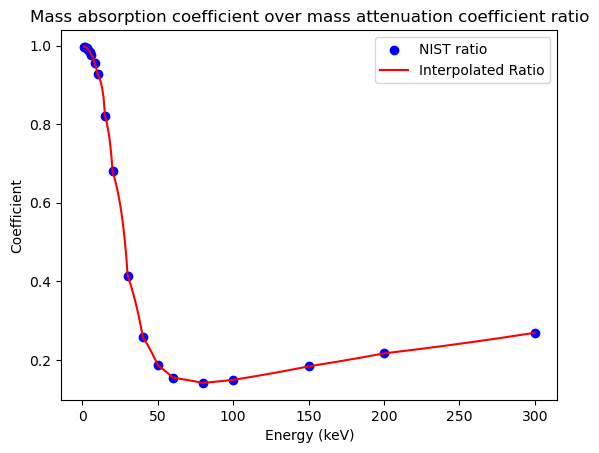

In [4]:
#Linear interpolation between existing points
for i in range(len(NIST)):
    if i!=len(NIST)-1:
        first_point = i
        second_point = i+1

        first_energy = NIST.loc[first_point, 'Energy']
        second_energy = NIST.loc[second_point, 'Energy']

        first_massatt = NIST.loc[first_point, 'Mass Att']
        second_massatt = NIST.loc[second_point, 'Mass Att']

        first_massen = NIST.loc[first_point, 'Mass En Abs']
        second_massen = NIST.loc[second_point, 'Mass En Abs']

        if (second_energy-first_energy) > 1:
            #interpolate
            interpolated_energies = np.arange(first_energy+1, second_energy, 1)
            xvals = np.array([first_energy, second_energy])

            interpolated_massatt = np.interp(interpolated_energies, xvals, np.array([first_massatt, second_massatt]))
            interpolated_massen = np.interp(interpolated_energies, xvals, np.array([first_massen, second_massen]))
            
            for en in interpolated_energies:
                Expanded_data.loc[Expanded_data['Energy']==en,'Mass Att'] = interpolated_massatt[np.where(interpolated_energies==en)]
                Expanded_data.loc[Expanded_data['Energy']==en,'Mass En Abs'] = interpolated_massen[np.where(interpolated_energies==en)]

Expanded_data['Ratio'] = Expanded_data['Mass En Abs']/Expanded_data['Mass Att']
print(Expanded_data)   

plt.scatter(NIST['Energy'],NIST['Ratio'], color='b', label='NIST ratio')
plt.plot(Expanded_data['Energy'], Expanded_data['Ratio'], color='r', label='Interpolated Ratio')
plt.title('Mass absorption coefficient over mass attenuation coefficient ratio')
plt.xlabel('Energy (keV)')
plt.ylabel('Coefficient')
plt.legend()        

# Calculate absorption factor

In [ ]:
#Thickness of material
x = 0.2 #cm
#Calculate absorption of each energy as 1-exp(-mu*x)
for i in range(len(Expanded_data)):
    Expanded_data.loc[i, 'Absorption'] = 1 - np.exp(-1*Expanded_data.loc[i,'Mass Att']*x)

print(Expanded_data)


     Energy  Mass Att Mass En Abs     Ratio  Absorption
0         1    4078.0      4065.0  0.996812    1.000000
1         2     617.3       615.2  0.996598    1.000000
2         3     192.9       191.7  0.993779    1.000000
3         4     82.78       81.91   0.98949    1.000000
4         5     42.58       41.88   0.98356    0.999800
..      ...       ...         ...       ...         ...
295     296  0.119336     0.03183  0.266726    0.023585
296     297  0.119152    0.031852  0.267327    0.023549
297     298  0.118968    0.031875  0.267929    0.023513
298     299  0.118784    0.031897  0.268534    0.023477
299     300    0.1186     0.03192   0.26914    0.023441

[300 rows x 5 columns]


# Read in spectrum from SpekCalc

     Energy           N
0        23  5173756.00
1        24  6060958.00
2        25  6872044.00
3        26  7673581.00
4        27  8395098.00
..      ...         ...
198     221   134945.20
199     222   100379.00
200     223    66337.49
201     224    32881.67
202     225        0.00

[203 rows x 2 columns]


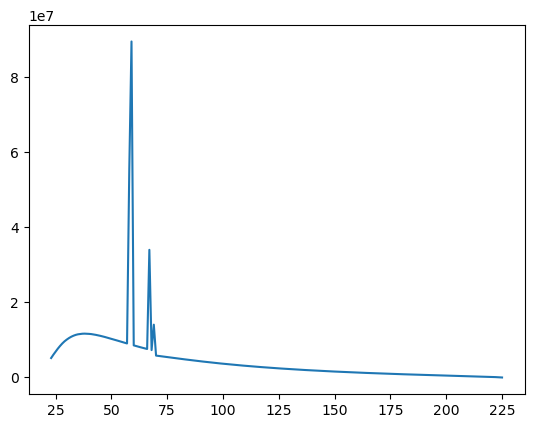

In [13]:
spectrum = pd.read_csv(r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\X-ray spectrum calculations\225kVp 30deg 525Air 2Be 2Al 0Cu 0Sn 0W 0Ta 0Ti 0C 0Wa.spec", sep=' ')
spectrum = spectrum[['Energy', 'N']].copy()
print(spectrum)
plt.plot(spectrum['Energy'], spectrum['N'])

# Calculations with spectrum

C:\Users\bhaan\AppData\Local\Temp\ipykernel_10652\1446717022.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  vals[i] = fluence*energy*ratio*factor


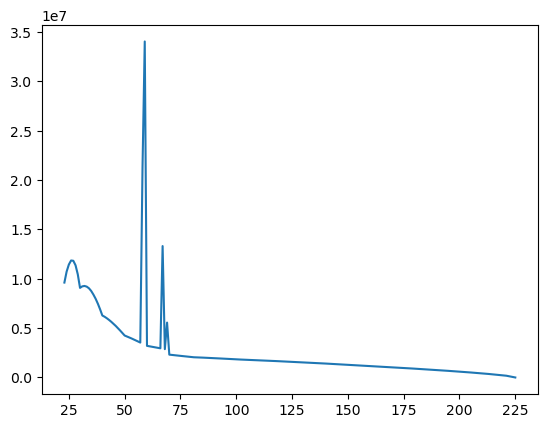

In [30]:
vals = np.zeros(len(spectrum))
for i in range(len(spectrum)):
    energy = spectrum.loc[i, 'Energy']
    fluence = spectrum.loc[i, 'N']

    #Ratio
    ratio = Expanded_data.loc[Expanded_data['Energy']==energy, 'Ratio']

    #Absorption factor
    factor = Expanded_data.loc[Expanded_data['Energy']==energy, 'Absorption']

    #Resulting energy
    vals[i] = fluence*energy*ratio*factor

spectrum['En'] = vals
plt.plot(spectrum['Energy'], spectrum['En'])
